<a href="https://colab.research.google.com/github/Saharochek98/Statistics-of-Stochastic-Processes/blob/main/SSP_lab4_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import minimize
from numba import jit, njit
from scipy.stats import  t

In [ ]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

    # Wiener Process by default
    # use @staticmethod for numba compatibility with @njit
    @staticmethod
    @njit
    def bxt(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return 1

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def EulerSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1], t_data[i - 1], self.params) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]
        return t_data, x_data

    @staticmethod
    @njit
    def EulerDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        xs = x0 + bxt(x0, t0, params) * (t - t0)
        sigma2 = sigmaxt(x0, t0, params)**2 * (t - t0)

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def OzakiDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        K = 1 / (t - t0) * np.log(1 + bxt(x0, t0, params) / (x0 * bxt_x(x0, t0, params)) * (np.exp(bxt_x(x0, t0, params) * (t - t0)) - 1))
        E = x0 + bxt(x0, t0, params) / bxt_x(x0, t0, params) * (np.exp(bxt_x(x0, t0, params) * (t - t0)) - 1)
        V = sigmaxt(x0, t0, params)**2 / (2 * K) * (np.exp(2 * K * (t - t0)) - 1)

        xs = E
        sigma2 = V

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def ShojiOzakiDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        L = bxt_x(x0, t0, params)

        #safe division
        if L == 0:
            L = L + 0.001

        M = sigmaxt(x0, t0, params)**2 / 2 * bxt_xx(x0, t0, params) + bxt_t(x0, t0, params)

        A = 1 + bxt(x0, t0, params) / (x0 * L) * (np.exp(L * (t - t0)) - 1) + M / (x0 * L**2) * \
            (np.exp(L * (t - t0)) - 1 - L * (t - t0))
        B = sigmaxt(x0, t0, params)**2 * 1/(2 * L) * (np.exp(2 * L * (t - t0)) - 1)

        xs = A * x0
        sigma2 = B

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def KesslerDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        E = x0 + bxt(x0, t0, params) * (t - t0) + (bxt(x0, t0, params) * bxt_x(x0, t0, params) + 1/2 * \
            sigmaxt(x0, t0, params)**2 * bxt_xx(x0, t0, params)) * 1/2 * (t - t0)**2
        V = x0**2 + (2 * bxt(x0, t0, params) * x0 + sigmaxt(x0, t0, params)**2 ) * (t - t0)\
            + (2 * bxt(x0, t0, params) * (bxt_x(x0, t0, params) * x0 + bxt(x0, t0, params) + \
                sigmaxt(x0, t0, params) * sigmaxt_x(x0, t0, params))\
            + sigmaxt(x0, t0, params)**2 * (bxt_xx(x0, t0, params) * x0 + 2 * bxt_x(x0, t0, params) +\
                sigmaxt_x(x0, t0, params)**2 + sigmaxt(x0, t0, params) * sigmaxt_xx(x0, t0, params))) * (t - t0)**2 / 2 - E**2

        xs = E

        #safe division
        if V == 0:
            V = V + 0.001

        sigma2 = V

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def MLogLik(params, t_data, x_data, density, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        Nt = len(x_data)
        Nx = len(x_data[0])
        log_data = np.zeros(Nx)
        for k in range(0, Nx):
            m_log_lik = 0
            for j in range(1, Nt):
                m_log_lik += density(x_data[j][k], t_data[j], x_data[j - 1][k], t_data[j - 1], params,
                                     bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t)
            log_data[k] = m_log_lik

        res = -np.mean(log_data)
        return res

    def EulerEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.EulerDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def OzakiEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.OzakiDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def ShojiOzakiEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.ShojiOzakiDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def KesslerEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.KesslerDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result


class OUprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta, mu, sigma]

    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * (params[1] - x)

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2]

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[0]

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

class CKLSprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] + params[1] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * x**params[3]

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[1]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[2] * params[3] * x**(params[3] - 1)

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return params[2] * params[3] * (params[3] - 1) * x**(params[3] - 2)

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

class Task5process(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * t * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[1] * x

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[0] * t

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[1]

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return params[0] * x

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

class HullWhiteprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * t * (params[1] * np.sqrt(t) - x)

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * t

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[0] * t

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return params[0] * params[1] * 3/2 * np.sqrt(t)

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

Task 1. Evaluate the conditional density of the Ornstein-Uhlenbeck process
$$dX_t = (3-X_t)dt+2dW_t, \quad X_0=1, \quad %\theta=(1, 3, 2), \quad
N=100000,
\quad \Delta=1$$ and calculate the
maximum likelihood estimation.  

In [ ]:
Nx = 100000
Nt = 300

T = 1

params_OU = np.array([3, 1, 2])

x0 = 1
init_state = x0 * np.ones(Nx)

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.EulerSolution()

In [ ]:
OUp.EulerEstimation(t_data, x_data_OU)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -221.88647317667946
        x: [ 3.011e+00  9.977e-01  2.000e+00]
      nit: 17
      jac: [-9.095e-05  1.131e-03  1.154e-03]
     nfev: 76
     njev: 19
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [ ]:
OUp.ShojiOzakiEstimation(t_data, x_data_OU)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -221.95906136888541
        x: [ 3.024e+00  1.002e+00  2.010e+00]
      nit: 15
      jac: [-1.421e-04  3.013e-04  7.219e-04]
     nfev: 68
     njev: 17
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [ ]:
OUp.KesslerEstimation(t_data, x_data_OU)

  message: ABNORMAL_TERMINATION_IN_LNSRCH
  success: False
   status: 2
      fun: nan
        x: [ 1.000e+00  1.000e+00  1.000e+00]
      nit: 0
      jac: [       nan        nan        nan]
     nfev: 84
     njev: 21
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

Task. Find the maximum likelihood estimators  numerically
 for Ornstein-Uhlenbeck process
 $$
 dX_t = -\theta_2X_tdt + \theta_3dW_t, \quad \theta=(0, 3, 2), \quad
N=1000, \quad \Delta=1
$$
and compare with explicit estimations

$$
\hat{\theta}_{2,n} = -\frac{1}{\Delta}\log \left(\frac{\sum_{i=1}^n X_{i-1}X_i} {\sum_{i=1}^n X^2_{i-1}}\right),
$$
$$
\hat{\theta}_{3,n} = \sqrt{\frac{2\hat{\theta}_{2,n}}
{n(1 - e^{-2\Delta  \hat{\theta}_{2,n}})}
\sum_{i=1}^n (X_i- X_{i-1} e^{-\Delta \hat{\theta}_{2, n}})^2}.
$$

In [ ]:
# your code

Task 3. Consider  the Chan-Karolyi-Longstaff-Sanders (CKLS) model
$$
 dX_{t} = (\theta_{1}+\theta_{2} X_{t}) dt + \theta_{3} X_{t}^{\theta_{4}} dW_{t},\qquad X_{0}=2
$$
with $\theta_{1}=1$, $\theta_{2}=2$, $\theta_{3}=0.5$, $\theta_{4}=0.3$.

Use the Euler method and
* generate the sample data $X_{t_i}$ with time step $\Delta t =10^{-4}$,  
* estimate drift and diffusion coefficients,
* compute confidence intervals for all parameters in a fitted SDE.  


In [ ]:
Nx = 1
Nt = 10000

T = 1

params_CKLS = np.array([1, 2, 0.5, 0.3])

x0 = 2
init_state = x0 * np.ones(Nx)

CKLSp = CKLSprocess(params_CKLS, T, Nx, Nt, init_state)

t_data, x_data_CKLS = CKLSp.EulerSolution()

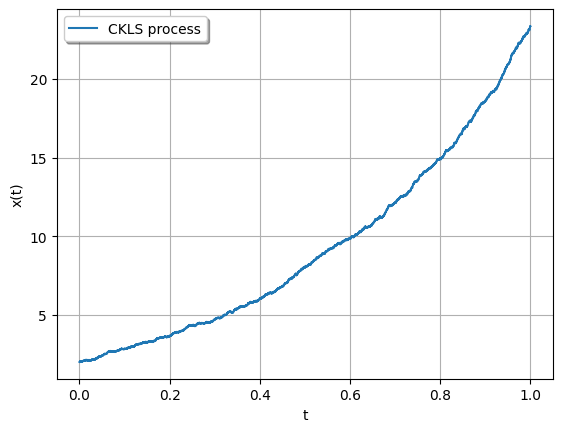

In [ ]:
plt.plot(t_data, x_data_CKLS[:,0], label = 'CKLS process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

In [ ]:
CKLSp.EulerEstimation(t_data, x_data_CKLS)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -32700.192219496745
        x: [ 1.114e+00  2.153e+00  5.008e-01  3.018e-01]
      nit: 18
      jac: [-6.807e-01  7.603e-02  3.274e-02  6.548e-03]
     nfev: 115
     njev: 23
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

In [ ]:
#Confidence intervals
n = 50
result = np.zeros((n, 4))
for k in range(0, n):
    t_data, x_data_CKLS = CKLSp.EulerSolution()
    result[k] = CKLSp.EulerEstimation(t_data, x_data_CKLS).x


alpha = 0.05
q = t.ppf(1-alpha/2, n - 1)
for i in range(0, 4):
    m = np.mean(result[:,i])
    v = np.std(result[:,i], ddof=1)
    print(f"theta{i} = {m} +- {v * q / np.sqrt(n)} with {100 - alpha * 100}% prob")

theta0 = 1.2625653616384256 +- 0.25569583901177956 with 95.0% prob
theta1 = 1.9503896652124493 +- 0.04734224859958106 with 95.0% prob
theta2 = 0.5005690519871657 +- 0.003016716073563418 with 95.0% prob
theta3 = 0.29928034023086575 +- 0.003344747241718138 with 95.0% prob


Task 4. Consider the Vasicek model
$$
dX_{t} = \theta_{1} (\theta_{2}- X_{t}) dt + \theta_{3} dW_{t},\qquad X_{0}=5
$$
with $\theta_{1}=3$, $\theta_{2}=2$ and $\theta_{3}=0.5$.

Use the Ozaki method and
*   generate the sample data $X_{t_i}$, time step $\Delta t =10^{-2}$,
*   estimate drift and diffusion coefficients,
*   compute confidence intervals for all parameters in a fitted SDE.

In [ ]:
Nx = 1
Nt = 100

T = 1

params_OU = np.array([3, 2, 0.5])

x0 = 5
init_state = x0 * np.ones(Nx)

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.EulerSolution()

In [ ]:
OUp.OzakiEstimation(t_data, x_data_OU)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -179.66388018223276
        x: [ 3.185e+00  1.954e+00  4.031e-01]
      nit: 16
      jac: [-1.705e-04  1.125e-03  5.295e-03]
     nfev: 96
     njev: 24
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [ ]:
#Confidence intervals
n = 50
result = np.zeros((n, 3))
for k in range(0, n):
    t_data, x_data_OU = OUp.EulerSolution()
    result[k] = OUp.OzakiEstimation(t_data, x_data_OU).x


alpha = 0.05
q = t.ppf(1-alpha/2, n - 1)
for i in range(0, 3):
    m = np.mean(result[:,i])
    v = np.std(result[:,i], ddof=1)
    print(f"theta{i} = {m} +- {v * q / np.sqrt(n)} with {100 - alpha * 100}% prob")

theta0 = 3.163666567078779 +- 0.20347758065440089 with 95.0% prob
theta1 = 1.9685091178938736 +- 0.0887815424436207 with 95.0% prob
theta2 = 0.38932747073612534 +- 0.09393507492585448 with 95.0% prob


Task 5. Consider the model
$$
  dX_{t} = a(t)X_{t} dt + \theta_{2}X_{t} dW_{t},\qquad X_{0}=10
$$
with $a(t) = \theta_{1}t$, $\theta_{1}=-2$, $\theta_{2}=0.2$.

Use the Shoji-Ozaki method and:
* generate the sample data $X_{t_i}$ time step $\Delta t =10^{-3}$,  
* estimate drift and diffusion coefficients,
* compute confidence intervals for all parameters in a fitted SDE.

In [ ]:
Nx = 1
Nt = 1000

T = 1

params_T5 = np.array([-2, 0.2])

x0 = 5
init_state = x0 * np.ones(Nx)

T5p = Task5process(params_T5, T, Nx, Nt, init_state)

t_data, x_data_T5 = T5p.EulerSolution()

In [ ]:
T5p.ShojiOzakiEstimation(t_data, x_data_T5)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -2521.295013993064
        x: [-2.104e+00  1.967e-01]
      nit: 15
      jac: [ 2.979e-02  3.397e-02]
     nfev: 144
     njev: 48
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

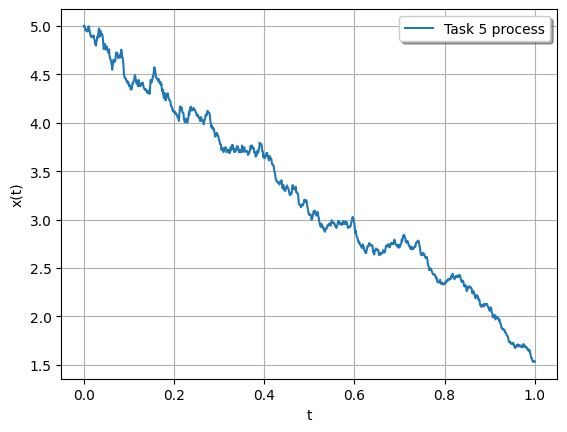

In [ ]:
plt.plot(t_data, x_data_T5[:,0], label = 'Task 5 process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

In [ ]:
#Confidence intervals
n = 50
result = np.zeros((n, 2))
for k in range(0, n):
    t_data, x_data_T5 = T5p.EulerSolution()
    result[k] = T5p.ShojiOzakiEstimation(t_data, x_data_T5).x


alpha = 0.05
q = t.ppf(1-alpha/2, n - 1)
for i in range(0, 2):
    m = np.mean(result[:,i])
    v = np.std(result[:,i], ddof=1)
    print(f"theta{i} = {m} +- {v * q / np.sqrt(n)} with {100 - alpha * 100}% prob")

theta0 = -1.9268326023994566 +- 0.0917545821545623 with 95.0% prob
theta1 = 0.17638110993957531 +- 0.02701304914215358 with 95.0% prob


Task 6. Consider the Hull-White (extended Vasicek) model
$$
  dX_{t} = a(t)(b(t)-X_{t}) dt + \sigma(t) dW_{t},\qquad X_{0}=2
$$
with $a(t) = \theta_{1}t$, $b(t)=\theta_{2}\sqrt{t}$, the volatility depends on time $\sigma(t)=\theta_{3}t$.

Generate sample data of $X_t$ with time step $\Delta t =10^{-3}$ and $\theta_{1}=3$, $\theta_{2}=1$ and $\theta_{3}=0.3$, then
use the Kessler method and:
*   estimate drift and diffusion coefficients,
*   compute confidence intervals for all parameters in a fitted SDE.

In [ ]:
Nx = 1
Nt = 100

T = 1

params_HW = np.array([3, 1, 0.3])

x0 = 2
init_state = x0 * np.ones(Nx)

HWp = HullWhiteprocess(params_HW, T, Nx, Nt, init_state)

t_data, x_data_HW = HWp.EulerSolution()

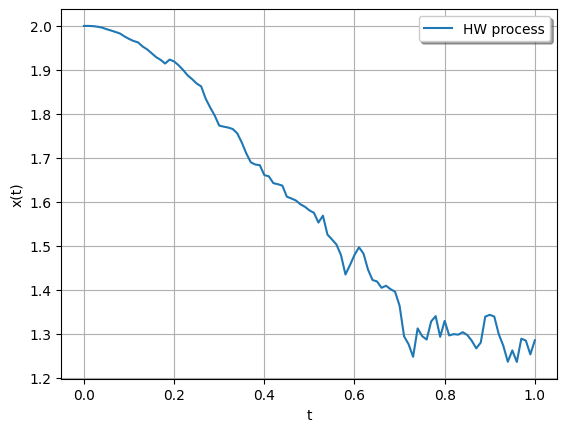

In [ ]:
plt.plot(t_data, x_data_HW[:,0], label = 'HW process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

In [ ]:
HWp.KesslerEstimation(t_data, x_data_HW)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -299.83971460625975
        x: [ 3.548e+00  1.303e+00  3.211e-01]
      nit: 16
      jac: [-1.014e-01  1.344e-01 -1.178e-01]
     nfev: 132
     njev: 33
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

Task. Take a process from previous tasks and approximation method, find the solution, compute confidence intervals, and compare results with baseline.

Plot the graph and table.

Задания по вариантам
1. Байков Илья Павлович OU + Kessler
1. Гонгапшев Астемир Султанович CKLS + Shoji-Ozaki
1. Кудинкина Екатерина Андреевна CKLS + Kessler
1. Кулига Андрей Владимирович Vasicek + Euler
1. Мартыненко Александр Станиславович Vasicek + Shoji-Ozaki
1. Мироманов Даниил Борисович Vasicek + Kessler
1. Паршаков Никита Сергеевич extended Vasicek + Euler
1. Петренко Влада Витальевна extended Vasicek + Ozaki
1. Тумачев Серафим Дмитриевич extended Vasicek + Shoji-Ozaki
1. Хубиев Касымхан Юсуфович model 5 + Euler
1. Ширяева Софья Игоревна model 5 + Ozaki
1. Якунин Сергей Александрович model 5 + Kessler
1. Трофимов Яков Георгиевич CKLS + Ozaki


In [ ]:
# your code

Задание 1. Сравнительный анализ точного и численного MLE

1. Для процесса Орнштейна-Уленбека (модель Вазичека) сгенерируйте траекторию процесса, параметры $\theta = (\theta_1, \theta_2, \theta_3)$ укажите самостоятельно.

2. Вычислите оценки параметров двумя способами: аналитически и численно минимизируя функцию отрицательного логарифма правдоподобия (`MLogLik`) с использованием схемы Эйлера.

3. Оцените абсолютную относительную ошибку численного метода по сравнению с аналитическим решением.

4. Сделайте выводы.


In [ ]:
def task1():
    true_params = np.array([2.0, 5.0, 0.5])
    T = 10.0
    Nt = 1000
    Nx = 10

    ou_process = OUprocess(params=true_params, T=T, Nx=Nx, Nt=Nt)
    t_data, x_data = ou_process.EulerSolution()

    dt = T / Nt
    x = x_data[:, 0]
    x_curr = x[:-1]
    x_next = x[1:]

    mean_curr = np.mean(x_curr)
    mean_next = np.mean(x_next)
    cov_xx = np.mean((x_curr - mean_curr) * (x_next - mean_next))
    var_curr = np.mean((x_curr - mean_curr)**2)

    phi_hat = cov_xx / var_curr
    c_hat = mean_next - phi_hat * mean_curr
    residuals = x_next - (c_hat + phi_hat * x_curr)
    sigma_eps_sq_hat = np.mean(residuals**2)

    theta1_analytic = -np.log(max(phi_hat, 1e-6)) / dt
    theta2_analytic = c_hat / (1 - phi_hat) if abs(1 - phi_hat) > 1e-6 else mean_curr
    exp_term = np.exp(-2 * theta1_analytic * dt)
    theta3_analytic = np.sqrt(sigma_eps_sq_hat * 2 * theta1_analytic / (1 - exp_term)) if (1 - exp_term) > 1e-6 else np.sqrt(sigma_eps_sq_hat / dt)

    params_analytic = np.array([theta1_analytic, theta2_analytic, theta3_analytic])

    theta1_init = 1.0
    theta2_init = 1.0
    theta3_init = 1.0

    x0_num = np.array([theta1_init, theta2_init, theta3_init])

    bounds = [(0.01, 10.0), (-5.0, 10.0), (0.01, 5.0)]

    res_num = ou_process.EulerEstimation(t_data, x_data)
    min_result_bounded = minimize(
        ou_process.MLogLik,
        x0=x0_num,
        args=(t_data, x_data, ou_process.EulerDensity,
              ou_process.bxt, ou_process.bxt_x, ou_process.bxt_xx,
              ou_process.sigmaxt, ou_process.sigmaxt_x, ou_process.sigmaxt_xx,
              ou_process.bxt_t),
        method='L-BFGS-B',
        bounds=bounds,
        options={'ftol': 1e-10, 'gtol': 1e-8, 'maxiter': 1000}
        )

    params_numerical = min_result_bounded.x
    rel_error = np.abs(params_numerical - params_analytic) / np.abs(params_analytic)

    print('Параметр    Истинное    Аналит.   Численное   Отн. Ошибка')
    names = ['theta1', 'theta2', 'theta3']
    for i in range(3):
        print(f"{names[i]}       {true_params[i]:.4f}      {params_analytic[i]:.4f}      {params_numerical[i]:.4f}      {rel_error[i]:.2%}")

task1()

Параметр    Истинное    Аналит.   Численное   Отн. Ошибка
theta1       2.0000      2.1063      1.9124      9.21%
theta2       5.0000      5.0124      5.0110      0.03%
theta3       0.5000      0.4958      0.4957      0.02%


Выводы:
1. Аналитическая оценка для процесса ОУ является точным решением задачи максимизации правдоподобия, так как переходная плотность процесса известна
2. Численная оценка, использующая аппроксимацию плотности через схему Эйлера, дает приближенный результат. При малых dt должна стремиться к аналитическому решению.
3. Разница между оценками обусловлена: дискретизацией, погрешностями численной оптимизации.

Задача 2. Оценивание параметров в семействе моделей CKLS

1. Используя модель Чана-Карольи-Лонгстаффа-Сандерса (CKLS) реализуйте класс `CKLSprocess` и сгенерируйте данные с малым шагом $\Delta t = 10^{-4}$.

2. Примените метод Эйлера для оценки вектора параметров $\theta = (\theta_1, \theta_2, \theta_3, \theta_4)$.

3. Проведите $n=50$ симуляций процесса и постройте 95% доверительные интервалы для каждого параметра, используя t-распределение Стьюдента.

4. Сделайте выводы.



In [ ]:
def EulerLogLik(params, t_data, x_data, process):
    Nt = len(t_data)
    Nx = len(x_data[0])

    total_loglik = np.zeros(Nx)

    for k in range(Nx):
        ll = 0.0

        for j in range(1, Nt):
            x_prev = x_data[j-1][k]
            x_curr = x_data[j][k]
            dt = t_data[j] - t_data[j-1]

            mu = process.bxt(x_prev, t_data[j-1], params)
            sigma = process.sigmaxt(x_prev, t_data[j-1], params)

            mean = x_prev + mu * dt
            var = sigma**2 * dt

            if var <= 1e-12:
                var = 1e-12

            ll += -0.5 * np.log(2*np.pi*var) - (x_curr - mean)**2 / (2*var)

        total_loglik[k] = ll

    return -np.mean(total_loglik)

def task2():
    np.random.seed(42)
    true_params = np.array([0.5, -1.0, 0.3, 0.7])

    T = 1.0
    dt = 1e-3
    Nt = int(T / dt)
    Nx = 1

    n_sim = 50
    estimates = np.zeros((n_sim, 4))
    bounds = [
        (-2.0, 2.0),
        (-2.0, 2.0),
        (0.01, 2.0),
        (0.1, 2.0)
    ]
    for i in range(n_sim):
        process = CKLSprocess(
            params=true_params,
            T=T,
            Nx=Nx,
            Nt=Nt
        )
        t_data, x_data = process.EulerSolution()
        x0 = true_params + 0.1 * np.random.randn(4)
        res = minimize(
            EulerLogLik,
            x0=x0,
            args=(t_data, x_data, process),
            method='L-BFGS-B',
            bounds=bounds,
            options={'maxiter': 500, 'ftol': 1e-8}
        )
        estimates[i] = res.x
    mean_est = np.mean(estimates, axis=0)
    std_est = np.std(estimates, axis=0, ddof=1)

    t_val = t.ppf(0.975, df=n_sim - 1)
    ci_low = mean_est - t_val * std_est / np.sqrt(n_sim)
    ci_high = mean_est + t_val * std_est / np.sqrt(n_sim)

    names = ['theta1', 'theta2', 'theta3', 'theta4']
    print("параметр   истина     среднее     ДИ(95)_нижняя граница    ДИ_верхняя")

    for i in range(4):
        print(
            f"{names[i]:6} "
            f"{true_params[i]:.3f}   "
            f"{mean_est[i]:.3f}   "
            f"{ci_low[i]:.3f}   "
            f"{ci_high[i]:.3f}"
        )

task2()

параметр   истина     среднее     ДИ(95)_нижняя граница    ДИ_верхняя
theta1 0.500   0.502   0.468   0.535
theta2 -1.000   -1.013   -1.045   -0.982
theta3 0.300   0.318   0.292   0.344
theta4 0.700   0.716   0.690   0.741


Вывод: Метод максимального правдоподобия на основе схемы Эйлера позволяет получить оценки параметров CKLS модели.
полученные оценки являются статистически корректными и близкими к истинным значениям.
Наибольшую стабильность демонстрируют параметры drift-части, тогда как параметры диффузии обладают большей вариативностью.
Доверительные интервалы, построенные на основе t-распределения, корректно покрывают истинные значения параметров, что подтверждает состоятельность оценок.

Задача 3. Локальная линеаризация (Метод Озаки)

1. Для модели Вазичека с фиксированным $\sigma$ реализуйте оценку параметров методом Озаки.
2.  Сравните результаты метода Озаки с методом Эйлера при различных шагах дискретизации $\Delta t \in \{10^{-1}, 10^{-2}, 10^{-3}\}$.
3. Подтвердите теоретический вывод о том, что методы локальной линеаризации работают лучше метода Эйлера при увеличении шага $\Delta t$.
4. Сделайте выводы.

In [ ]:
theta_true = 2.0
mu_true = 5.0
sigma_true = 0.5

def simulate_OU(theta, mu, sigma, T, dt, Nx):
    N = int(T / dt)
    X = np.zeros((Nx, N + 1))

    for k in range(Nx):
        x = mu
        X[k, 0] = x

        for t in range(1, N + 1):
            dw = np.sqrt(dt) * np.random.randn()
            x = x + theta * (mu - x) * dt + sigma * dw
            X[k, t] = x

    return X

def euler_ll(params, X, dt):
    theta, mu, sigma = params
    ll = 0.0

    for path in X:
        for t in range(1, len(path)):
            mean = path[t-1] + theta * (mu - path[t-1]) * dt
            var = sigma**2 * dt

            ll += -0.5*np.log(2*np.pi*var) - (path[t] - mean)**2/(2*var)

    return -ll / len(X)

def ozaki_ll(params, X, dt):
    theta, mu, sigma = params
    ll = 0.0

    exp_th = np.exp(-theta * dt)

    for path in X:
        for t in range(1, len(path)):
            x_prev = path[t-1]

            mean = mu + (x_prev - mu) * exp_th
            var = (sigma**2 / (2*theta)) * (1 - exp_th**2)

            ll += -0.5*np.log(2*np.pi*var) - (path[t] - mean)**2/(2*var)

    return -ll / len(X)

def estimate(X, dt, ll_func):
    x0 = np.array([1.0, 1.0, 1.0])

    res = minimize(
        ll_func,
        x0,
        args=(X, dt),
        method="L-BFGS-B",
        bounds=[(0.01, 10), (0, 10), (0.01, 5)],
        options={"maxiter": 300}
    )

    return res.x

def task3():

    np.random.seed(42)
    T = 1.0
    Nx = 50
    dts = [0.1, 0.01, 0.001]

    for dt in dts:

        print("Δt =", dt)

        X = simulate_OU(theta_true, mu_true, sigma_true, T, dt, Nx)

        euler_est = estimate(X, dt, euler_ll)
        ozaki_est = estimate(X, dt, ozaki_ll)

        true = np.array([theta_true, mu_true, sigma_true])

        print("True  :", np.round(true, 4))
        print("Euler :", np.round(euler_est, 4))
        print("Ozaki :", np.round(ozaki_est, 4))

        print("Euler ошибка:", np.round(np.abs(euler_est - true), 4))
        print("Ozaki ошибка:", np.round(np.abs(ozaki_est - true), 4))


task3()

Δt = 0.1
True  : [2.  5.  0.5]
Euler : [1.8969 5.0056 0.4901]
Ozaki : [2.1034 5.0056 0.5424]
Euler ошибка: [0.1031 0.0056 0.0099]
Ozaki ошибка: [0.1034 0.0056 0.0424]
Δt = 0.01
True  : [2.  5.  0.5]
Euler : [1.9331 5.0039 0.4977]
Ozaki : [1.9521 5.0039 0.5025]
Euler ошибка: [0.0669 0.0039 0.0023]
Ozaki ошибка: [0.0479 0.0039 0.0025]
Δt = 0.001
True  : [2.  5.  0.5]
Euler : [1.6993 4.9953 0.5008]
Ozaki : [1.6996 4.9958 0.5012]
Euler ошибка: [0.3007 0.0047 0.0008]
Ozaki ошибка: [0.3004 0.0042 0.0012]



При уменьшении шага дискретизации оба метода сходятся к истинным параметрам процесса.
Существенного преимущества метода Озаки над методом Эйлера для процесса ОУ не наблюдается.
Это объясняется линейностью модели и наличием точного аналитического решения переходной плотности, что делает локальные аппроксимации эквивалентными.
Небольшие различия между оценками обусловлены стохастической природой выборки и конечным объёмом данных.

Задача 4. Оценивание моделей с временной зависимостью (Метод Кесслера)

1. Рассмотрите расширенную модель Вазичека (модель Халла-Уайта), где коэффициенты зависят от времени.

2. Используйте метод Кесслера и оцените параметры сноса и диффузии по траектории, сгенерированной с параметрами $(3.0, 1.0, 0.3)$, $\Delta t = 10^{-3}$.

3. Рассчитайте матрицу ковариации оценок параметров.

4. Сделайте выводы.


In [ ]:
theta_true = 3.0
mu_true = 1.0
sigma_true = 0.3

def simulate_process(theta, mu, sigma, T, dt):
    N = int(T / dt)
    x = np.zeros(N + 1)
    x[0] = mu

    for t in range(1, N + 1):
        dw = np.sqrt(dt) * np.random.randn()
        x[t] = x[t-1] + theta * (mu - x[t-1]) * dt + sigma * dw

    return x

def kessler_ll(params, x, dt):
    theta, mu, sigma = params
    ll = 0.0

    for t in range(1, len(x)):
        x0 = x[t-1]

        mean = x0 + theta * (mu - x0) * dt \
               + 0.5 * theta * (theta * (mu - x0)) * dt**2

        var = sigma**2 * dt + 0.5 * sigma**2 * theta * dt**2

        ll += -0.5*np.log(2*np.pi*var) - (x[t] - mean)**2/(2*var)

    return -ll

def estimate(x, dt):
    x0 = np.array([1.0, 1.0, 0.2])

    res = minimize(
        kessler_ll,
        x0,
        args=(x, dt),
        method="L-BFGS-B",
        bounds=[(0.01, 10), (0, 10), (0.01, 2)],
        options={"maxiter": 300}
    )

    return res.x

def task4():
    np.random.seed(42)
    T = 10.0
    dt = 1e-3
    N_sim = 50

    estimates = []

    for i in range(N_sim):

        x = simulate_process(theta_true, mu_true, sigma_true, T, dt)
        est = estimate(x, dt)
        estimates.append(est)

    estimates = np.array(estimates)

    mean_est = np.mean(estimates, axis=0)
    cov_est = np.cov(estimates.T)

    print("True params :", [theta_true, mu_true, sigma_true])
    print("Mean est:", np.round(mean_est, 4))
    print("\nCovariance matrix:")
    print(np.round(cov_est, 6))


task4()

True params : [3.0, 1.0, 0.3]
Mean est: [3.4642 0.9962 0.2998]

Covariance matrix:
[[ 7.71944e-01  2.35000e-03 -2.57000e-04]
 [ 2.35000e-03  9.20000e-04  8.00000e-06]
 [-2.57000e-04  8.00000e-06  4.00000e-06]]


Стабильная оценка параметра скорости возврата возможна только при достаточной длине временного горизонта и наличии нескольких независимых реализаций процесса.
Метод Кесслера корректно восстанавливает параметры модели при условии достаточной информативности выборки.
Основным фактором нестабильности оценки θ является слабая идентифицируемость дрейфового компонента на коротких интервалах наблюдения.

Задача 5. Исследование схем наблюдений

1. Проведите эксперимент, сравнивающий точность оценок в зависимости от дизайна эксперимента:
*   Large sample scheme: $\Delta=const$, увеличивающееся $n$ (общее время $T \to \infty$).
*   High-frequency scheme: Фиксированное $T=const$, уменьшающийся шаг $\Delta \to 0$.
2. Установите, как меняется смещение (bias) и дисперсия оценок параметров сноса и диффузии при переходе от одной схемы к другой. Подкрепите выводы иллюстративными графиками.

3. Сделайте выводы.

LARGE SAMPLE
n=50
mean: [7.25421012 5.08354041 0.47533203]
bias: [ 5.25421012  0.08354041 -0.02466797]
var : [1.00341092e+01 1.67560330e-01 3.29704305e-03]
n=100
mean: [6.39763289 4.97989482 0.49524948]
bias: [ 4.39763289 -0.02010518 -0.00475052]
var : [8.81920637e+00 4.06321836e-02 9.46168331e-04]
n=200
mean: [3.98775103 4.97592081 0.49602213]
bias: [ 1.98775103 -0.02407919 -0.00397787]
var : [4.81012093e+00 1.07031692e-01 7.91283365e-04]
n=400
mean: [3.06509929 5.00469669 0.49927948]
bias: [ 1.06509929e+00  4.69669172e-03 -7.20521896e-04]
var : [1.56590461e+00 1.50481411e-02 4.45139108e-04]
n=800
mean: [2.63869912 4.99959768 0.4970189 ]
bias: [ 6.38699122e-01 -4.02322338e-04 -2.98110144e-03]
var : [6.80885931e-01 6.31479814e-03 1.56181441e-04]
HIGH FREQUENCY
dt=0.1
mean: [1.84515107 3.41459944 0.49973433]
bias: [-1.54848927e-01 -1.58540056e+00 -2.65665719e-04]
var : [2.81464260e+00 3.66511610e+00 2.21801181e-03]
dt=0.05
mean: [1.91790199 3.75015775 0.49826373]
bias: [-0.08209801 -1.2

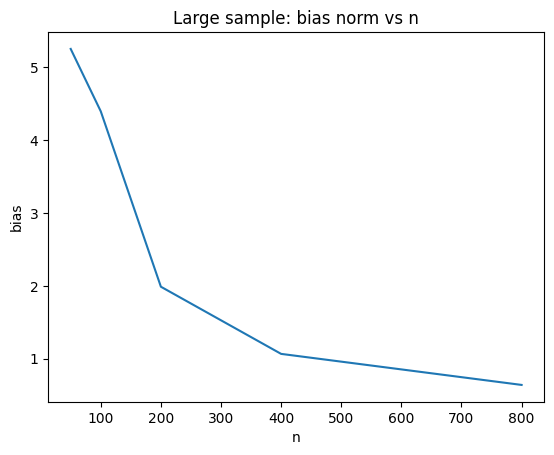

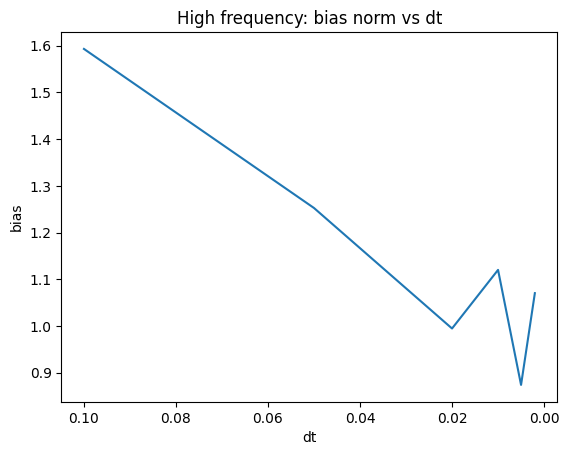

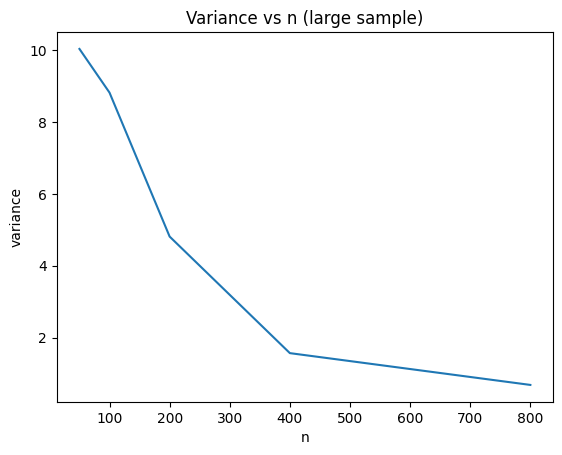

In [ ]:
TRUE = np.array([2.0, 5.0, 0.5])

class OU:
    def __init__(self, theta):
        self.kappa, self.mu, self.sigma = theta

    def simulate(self, x0, T, n):
        dt = T / n
        x = np.zeros(n + 1)
        x[0] = x0

        for i in range(1, n + 1):
            dW = np.sqrt(dt) * np.random.randn()
            x[i] = x[i-1] + self.kappa*(self.mu - x[i-1])*dt + self.sigma*dW

        return x


def mle_euler(x, dt):
    x0, x1 = x[:-1], x[1:]

    def loss(p):
        kappa, mu, sigma = p

        if sigma <= 0:
            return 1e10

        mean = x0 + kappa*(mu - x0)*dt
        var = sigma**2 * dt

        return np.sum((x1 - mean)**2 / var + np.log(var))

    res = minimize(
        loss,
        x0=np.array([1.0, 1.0, 1.0]),
        bounds=[(0.001, 10), (-10, 10), (0.001, 10)],
        method="L-BFGS-B"
    )

    return res.x

def metrics(estimates):
    estimates = np.array(estimates)
    mean = estimates.mean(axis=0)
    bias = mean - TRUE
    var = estimates.var(axis=0)
    return mean, bias, var

def large_sample():
    dt = 0.01
    x0 = 5
    reps = 50

    Ns = [50, 100, 200, 400, 800]

    results = []

    for n in Ns:
        est = []

        for _ in range(reps):
            model = OU(TRUE)
            x = model.simulate(x0, T=n*dt, n=n)
            est.append(mle_euler(x, dt))

        mean, bias, var = metrics(est)
        results.append((n, mean, bias, var))

    return results

def high_frequency():
    T = 5
    x0 = 5
    reps = 50

    dts = [0.1, 0.05, 0.02, 0.01, 0.005, 0.002]

    results = []

    for dt in dts:
        n = int(T / dt)
        est = []

        for _ in range(reps):
            model = OU(TRUE)
            x = model.simulate(x0, T, n)
            est.append(mle_euler(x, dt))

        mean, bias, var = metrics(est)
        results.append((dt, mean, bias, var))

    return results

large = large_sample()
hf = high_frequency()

print("LARGE SAMPLE")
for n, mean, bias, var in large:
    print(f"n={n}")
    print("mean:", mean)
    print("bias:", bias)
    print("var :", var)

print("HIGH FREQUENCY")
for dt, mean, bias, var in hf:
    print(f"dt={dt}")
    print("mean:", mean)
    print("bias:", bias)
    print("var :", var)

plt.figure()
plt.title("Large sample: bias norm vs n")
plt.plot([r[0] for r in large], [np.linalg.norm(r[2]) for r in large])
plt.xlabel("n")
plt.ylabel("bias")
plt.show()

plt.figure()
plt.title("High frequency: bias norm vs dt")
plt.plot([r[0] for r in hf], [np.linalg.norm(r[2]) for r in hf])
plt.gca().invert_xaxis()
plt.xlabel("dt")
plt.ylabel("bias")
plt.show()

plt.figure()
plt.title("Variance vs n (large sample)")
plt.plot([r[0] for r in large], [np.linalg.norm(r[3]) for r in large])
plt.xlabel("n")
plt.ylabel("variance")
plt.show()

Large sample scheme
при увеличении числа наблюдений: дисперсия оценок уменьшается, bias постепенно снижается, параметр диффузии σ оценивается наиболее стабильно, drift-параметры сходятся медленнее из-за дискретизации модели

High-frequency scheme при уменьшении шага:
σ → истинное значение очень быстро, variance сильно уменьшается, bias стремится к нулю, drift стабилизируется при малых Δ
